In [1]:
# Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(torch.cuda.get_device_capability())

PyTorch: 2.9.1+cu128
CUDA: True
(12, 0)


In [2]:
# Configuration
CONFIG = {
    "batch_size": 32,
    "epochs": 10,
    "learning_rate": 0.001,
    "num_classes": 38,
    "image_size": 224,
    "data_dir": "../data/raw/plantvillage",
    "train_dir": "../data/raw/plantvillage/train",
    "val_dir": "../data/raw/plantvillage/val",
    "model_path": "../models/mobilenetv2_agrivision.pt",
}

# Force CPU due to CUDA compatibility issues with RTX 5060 Ti (sm_120)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

Using: cuda


In [3]:
# Data Transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# Load Dataset
train_dataset = datasets.ImageFolder(CONFIG["train_dir"], transform=train_transform)
val_dataset = datasets.ImageFolder(CONFIG["val_dir"], transform=val_transform)

# Set num_workers=0 to avoid shared memory error in Docker
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Training samples: 43444
Validation samples: 10861
Number of classes: 38
Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria

In [ ]:
# Create Model with Transfer Learning
# Using MobileNetV2 pre-trained on ImageNet
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze the convolutional base for initial training (optional: unfreeze for fine-tuning)
for param in model.features.parameters():
    param.requires_grad = True  # Set to False to freeze, True to fine-tune

# Replace classifier with custom dense layers:
# - Global Average Pooling (built into MobileNetV2 before classifier)
# - Dense layer (128 neurons, ReLU activation) for feature extraction
# - Softmax Output layer (38 neurons) for disease classification
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(1280, 128),           # Dense layer with 128 neurons
    nn.ReLU(),                       # ReLU activation
    nn.Linear(128, CONFIG["num_classes"]),  # Output layer (38 neurons)
)

model = model.to(DEVICE)
print(f"Model created with custom top layers:")
print(f"  - Global Average Pooling (1280 features)")
print(f"  - Dense: 128 neurons, ReLU activation")
print(f"  - Output: {CONFIG['num_classes']} neurons (Softmax)")
print(model.classifier)

Model created with 38 output classes


In [ ]:
# Training Functions
# Loss: CrossEntropyLoss (combines LogSoftmax + NLLLoss, equivalent to categorical cross-entropy)
# Optimizer: Adam - adaptive learning rate optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

print(f"Loss Function: CrossEntropyLoss (Categorical Cross-Entropy)")
print(f"Optimizer: Adam (lr={CONFIG['learning_rate']})")

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), correct / total

In [7]:
# Training Loop
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(CONFIG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/10


Validating: 100%|██████████| 340/340 [00:18<00:00, 18.39it/s]


Train Loss: 0.3096, Train Acc: 0.9040
Val Loss: 0.1110, Val Acc: 0.9656

Epoch 2/10


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.13it/s]


Train Loss: 0.1508, Train Acc: 0.9517
Val Loss: 0.4030, Val Acc: 0.8840

Epoch 3/10


...

Train Loss: 0.0705, Train Acc: 0.9778
Val Loss: 0.0315, Val Acc: 0.9913

Epoch 9/10


Validating: 100%|██████████| 340/340 [00:16<00:00, 20.14it/s]


Train Loss: 0.0568, Train Acc: 0.9822
Val Loss: 0.0769, Val Acc: 0.9784

Epoch 10/10


Validating: 100%|██████████| 340/340 [00:19<00:00, 17.12it/s]

Train Loss: 0.0655, Train Acc: 0.9794
Val Loss: 0.0341, Val Acc: 0.9889


In [8]:
# Save Model
os.makedirs(os.path.dirname(CONFIG["model_path"]), exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": train_dataset.classes,
    "config": CONFIG
}, CONFIG["model_path"])

print(f"Model saved to {CONFIG['model_path']}")

Model saved to ../models/mobilenetv2_agrivision.pt


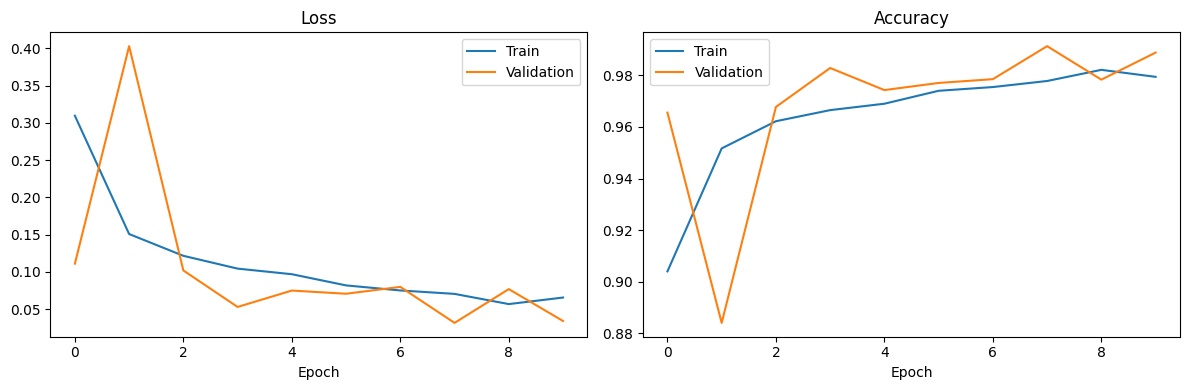

In [9]:
# Visualize Results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses, label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accs, label='Train')
axes[1].plot(val_accs, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('../models/training_history.png')
plt.show()

Mean accuracy of last 3 epoch: 98.94%
Best single epoch accuracy: 99.13%